<a href="https://colab.research.google.com/github/Lordyblade/BigData26_B_2411532010_IbrahimMousaDhani/blob/main/Praktikum1/BD_B_P01_2411532010_Ibrahim_Mousa_Dhani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
#J-1
import sys, platform, multiprocessing

print("Python    :", sys.version.split()[0])
print("OS        :", platform.platform())
print("CPU core  :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

!free -h
!df -h /content
!java -version

Python    : 3.13.15
OS        : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core  : 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       3.5Gi       7.5Gi       3.9Mi       2.1Gi       9.2Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  21% /
[0.005s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.005s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [27]:
#J-2
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'distribusi_per_jam.png', 'pengukuran_kinerja.csv', 'TugasPraktikum']


In [28]:
#J-3
import time, os, psutil
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2), "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS delta: {delta:+.1f} MB")
    return hasil

In [29]:
#J-4
import urllib.request
URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

import pyarrow.parquet as pq
meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Ukuran file: 45.5 MB
Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [30]:
#J-5
import pandas as pd
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

# Penurunan Pemakaian Memori
sebelum = df.memory_usage(deep=True).sum() / 1024**2
df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

[baca semua kolom] 2.66 s | RSS delta: +435.2 MB
Dimensi: (3066766, 19)
Memori: 565.6 MB
[baca kolom terpilih] 0.87 s | RSS delta: +163.8 MB
Dimensi: (3066766, 8)
Memori: 187.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB
187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [31]:
#J-6
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom: \n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom: 
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)
3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


In [32]:
#J-7
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))
print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 38.77 s | RSS delta: +0.0 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 6.54 s | RSS delta: +0.5 MB
2,986,911 baris | rata-rata total_amount = 27.33


In [34]:
#J-8
!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
  SELECT payment_type,
       COUNT(*) AS jumlah,
       ROUND(AVG(total_amount), 2) AS rata_tarif,
       ROUND(AVG(tip_amount), 2) AS rata_tip
  FROM trips
  GROUP BY payment_type
  ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Spark: 3.5.1
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare

In [35]:
#J-9
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


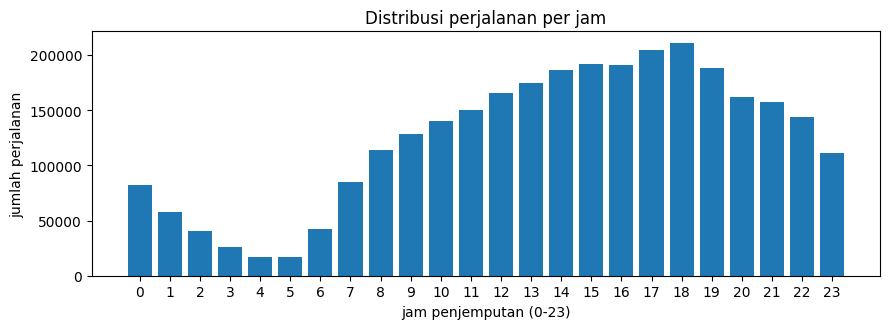

In [36]:
#J-10
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("jam penjemputan (0-23)")
ax.set_ylabel("jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0,24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

Studi Kasus

=== Tabel ringkas: jumlah, durasi, dan tarif/menit per jam (hari kerja vs akhir pekan) ===
 akhir_pekan  jam  jumlah  rata_durasi  rata_tarif_per_menit
       False    0   35351        14.10                  2.57
       False    1   17516        13.04                  2.66
       False    2    9452        12.23                  2.63
       False    3    6238        12.87                  2.72
       False    4    6192        14.79                  2.81
       False    5   12462        14.63                  2.82
       False    6   35728        14.57                  2.33
       False    7   74157        14.66                  2.07
       False    8   98431        14.82                  1.90
       False    9  103263        15.03                  1.90
       False   10  105228        15.24                  1.89
       False   11  108784        15.25                  1.86
       False   12  117281        15.04                  1.90
       False   13  123446        15.50                 

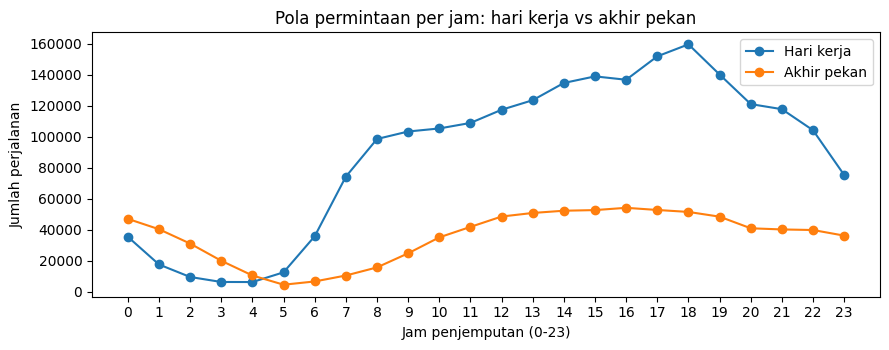

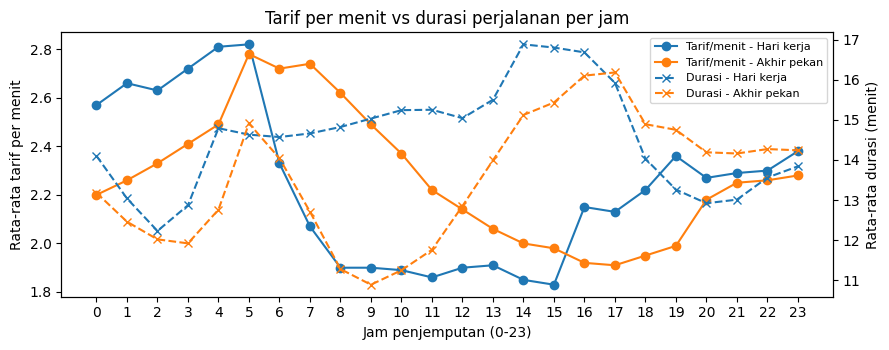

In [41]:
import matplotlib.pyplot as plt

bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

# TABEL (menjawab Q1 & Q2: jam puncak/terendah, beda hari kerja vs akhir pekan)
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

print("=== Tabel ringkas: jumlah, durasi, dan tarif/menit per jam (hari kerja vs akhir pekan) ===")
print(ringkas.to_string(index=False))

# GRAFIK 1 (menjawab Q1 & Q2: pola jumlah perjalanan per jam)
fig1, ax1 = plt.subplots(figsize=(9, 3.6))
for status, label in [(False, "Hari kerja"), (True, "Akhir pekan")]:
    data = ringkas[ringkas["akhir_pekan"] == status]
    ax1.plot(data["jam"], data["jumlah"], marker="o", label=label)
ax1.set_xlabel("Jam penjemputan (0-23)")
ax1.set_ylabel("Jumlah perjalanan")
ax1.set_title("Pola permintaan per jam: hari kerja vs akhir pekan")
ax1.set_xticks(range(0, 24))
ax1.legend()
fig1.tight_layout()
fig1.savefig(f"{DIR_SIMPAN}/studi_kasus_permintaan_per_jam.png", dpi=150)
plt.show()

# GRAFIK 2 (menjawab Q3: jam sibuk lebih pendek tapi lebih untung per menit?)
fig2, ax2 = plt.subplots(figsize=(9, 3.6))
for status, label in [(False, "Hari kerja"), (True, "Akhir pekan")]:
    data = ringkas[ringkas["akhir_pekan"] == status]
    ax2.plot(data["jam"], data["rata_tarif_per_menit"], marker="o", label=f"Tarif/menit - {label}")
ax2b = ax2.twinx()
for status, label in [(False, "Hari kerja"), (True, "Akhir pekan")]:
    data = ringkas[ringkas["akhir_pekan"] == status]
    ax2b.plot(data["jam"], data["rata_durasi"], marker="x", linestyle="--", label=f"Durasi - {label}")
ax2.set_xlabel("Jam penjemputan (0-23)")
ax2.set_ylabel("Rata-rata tarif per menit")
ax2b.set_ylabel("Rata-rata durasi (menit)")
ax2.set_title("Tarif per menit vs durasi perjalanan per jam")
ax2.set_xticks(range(0, 24))
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
fig2.tight_layout()
fig2.savefig(f"{DIR_SIMPAN}/studi_kasus_tarif_vs_durasi.png", dpi=150)
plt.show()

ringkas.to_csv(f"{DIR_SIMPAN}/studi_kasus_ringkas_per_jam.csv", index=False)

Latihan

In [50]:
print("=== Latihan 1: 5 trip_distance terbesar ===")
top5_jarak = bersih.nlargest(5, "trip_distance")
display(top5_jarak[['trip_distance', 'durasi_menit', 'total_amount']])

=== Latihan 1: 5 trip_distance terbesar ===


,trip_distance,durasi_menit,total_amount
1748933,96.70,136.416667,440.750000
526988,93.05,96.333333,564.049988
2402193,92.60,143.083333,312.799988
2902389,92.00,148.500000,368.149994
927215,90.63,114.050000,272.299988


In [51]:
print("\n=== Latihan 2: Perbandingan chunksize ===")

for ukuran in [100_000, 1_000_000]:
    baris, total, per_jam_chunk = ukur(
        f"agregasi chunking (chunksize={ukuran})",
        lambda u=ukuran: agregasi_bertahap(CSV, ukuran_chunk=u)
    )
    print(f"chunksize={ukuran:>9,} -> {baris:,} baris | rata-rata total_amount = {total/baris:.2f}")


=== Latihan 2: Perbandingan chunksize ===
[agregasi chunking (chunksize=100000)] 7.07 s | RSS delta: +5.9 MB
chunksize=  100,000 -> 2,986,911 baris | rata-rata total_amount = 27.33
[agregasi chunking (chunksize=1000000)] 3.90 s | RSS delta: +39.4 MB
chunksize=1,000,000 -> 2,986,911 baris | rata-rata total_amount = 27.33


In [52]:
print("\n=== Latihan 3: Persentase tip per payment_type ===")

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] == 0,
    np.nan,
    (bersih["tip_amount"] / bersih["fare_amount"] * 100)
)

rata_persen_tip = (bersih
    .groupby("payment_type")["persen_tip"]
    .mean()
    .round(2)
    .reset_index())
print(rata_persen_tip)


=== Latihan 3: Persentase tip per payment_type ===
  payment_type  persen_tip
0            0   20.219999
1            1   25.910000
2            2    0.000000
3            3    0.020000
4            4    0.150000


/tmp/ipykernel_5103/611845019.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("payment_type")["persen_tip"]


In [53]:
print("\n=== Latihan 4: Perbandingan kompresi Parquet ===")

PATH_SNAPPY = f"{DIR_KERJA}/bersih_snappy.parquet"
PATH_GZIP   = f"{DIR_KERJA}/bersih_gzip.parquet"

ukur("tulis parquet snappy", lambda: bersih.to_parquet(PATH_SNAPPY, index=False, compression="snappy"))
ukur("tulis parquet gzip",   lambda: bersih.to_parquet(PATH_GZIP,   index=False, compression="gzip"))

print("Ukuran snappy:", round(os.path.getsize(PATH_SNAPPY) / 1024**2, 1), "MB")
print("Ukuran gzip  :", round(os.path.getsize(PATH_GZIP) / 1024**2, 1), "MB")


=== Latihan 4: Perbandingan kompresi Parquet ===
[tulis parquet snappy] 2.00 s | RSS delta: -0.6 MB
[tulis parquet gzip] 43.67 s | RSS delta: +27.1 MB
Ukuran snappy: 63.3 MB
Ukuran gzip  : 51.0 MB


In [54]:
print("\n=== Latihan 5: Verifikasi konsistensi pandas vs Spark SQL ===")

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01-Latihan5")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH)
sdf_bersih = (sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

sdf_bersih.createOrReplaceTempView("trips")
agregasi_spark_sql = spark.sql("""
    SELECT HOUR(tpep_pickup_datetime) AS jam,
           COUNT(*) AS jumlah
    FROM trips
    GROUP BY jam
    ORDER BY jam
""").toPandas()

# Bandingkan dengan agregasi pandas (dari J-9)
agregasi_pandas_jumlah = agregasi[["jam", "jumlah_perjalanan"]].rename(
    columns={"jumlah_perjalanan": "jumlah"})

bandingan = agregasi_pandas_jumlah.merge(
    agregasi_spark_sql, on="jam", suffixes=("_pandas", "_spark"))
bandingan["selisih"] = bandingan["jumlah_pandas"] - bandingan["jumlah_spark"]

print(bandingan)
print("\nSelisih maksimum:", bandingan["selisih"].abs().max())

spark.stop()


=== Latihan 5: Verifikasi konsistensi pandas vs Spark SQL ===
    jam  jumlah_pandas  jumlah_spark  selisih
0     0          82289         82289        0
1     1          57766         57766        0
2     2          40445         40445        0
3     3          26146         26146        0
4     4          16618         16618        0
5     5          16940         16940        0
6     6          42300         42300        0
7     7          84569         84569        0
8     8         114064        114064        0
9     9         127988        127988        0
10   10         140230        140230        0
11   11         150539        150539        0
12   12         165714        165714        0
13   13         174183        174183        0
14   14         186741        186741        0
15   15         191392        191392        0
16   16         190689        190689        0
17   17         204399        204399        0
18   18         210858        210858        0
19   19         1